In [1]:
# =============================================================================
# ANÁLISIS DE DATOS DE SALUD MENTAL - DATATÓN DE CHEVES Y DATOS 2026
# Secretaría de Participación Ciudadana del Estado de Nuevo León
# =============================================================================

# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")

Librerías cargadas correctamente
Versión de pandas: 2.2.3
Versión de numpy: 2.0.2


In [ ]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [6]:
# =============================================================================
# 2. CARGA Y LIMPIEZA DE DATOS
# =============================================================================

# Cargar el dataset
df = pd.read_csv('2024_2025_salud_mental.csv')

# Información básica del dataset
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Total de registros: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")
print(f"\nColumnas: {df.columns.tolist()}")

# Reemplazar "sin valor" por NaN para mejor manejo
df = df.replace('sin valor', np.nan)

# Convertir tipos de datos
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
df['edad'] = pd.to_numeric(df['edad'], errors='coerce')
df['peso'] = pd.to_numeric(df['peso'], errors='coerce')
df['altura'] = pd.to_numeric(df['altura'], errors='coerce')

# Calcular IMC donde sea posible
df['imc'] = df['peso'] / ((df['altura']/100) ** 2)

# Clasificación del IMC
def clasificar_imc(imc):
    if pd.isna(imc):
        return 'Sin dato'
    elif imc < 18.5:
        return 'Bajo peso'
    elif imc < 25:
        return 'Peso normal'
    elif imc < 30:
        return 'Sobrepeso'
    else:
        return 'Obesidad'

df['categoria_imc'] = df['imc'].apply(clasificar_imc)

=== INFORMACIÓN DEL DATASET ===
Total de registros: 48224
Total de columnas: 14

Columnas: ['fecha', 'id_consulta', 'edad', 'edad_meses', 'edad_dias', 'sexo', 'peso', 'altura', 'municipio_unidad_medica', 'institucion_unidad_medica', 'clave_grupo_ enfermedad', 'descripcion_grupo_enfermedad', 'clave_enfermedad', 'descripcion_enfermedad']


In [4]:
# =============================================================================
# 3. ANÁLISIS EXPLORATORIO DE DATOS
# =============================================================================

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\n=== VALORES FALTANTES ===")
print(df.isnull().sum())

print("\n=== DISTRIBUCIÓN POR MUNICIPIO ===")
print(df['municipio_unidad_medica'].value_counts())

print("\n=== DISTRIBUCIÓN POR GÉNERO ===")
print(df['sexo'].value_counts())

print("\n=== GRUPOS DE ENFERMEDAD MÁS COMUNES ===")
print(df['descripcion_grupo_enfermedad'].value_counts())

print("\n=== DIAGNÓSTICOS MÁS COMUNES (TOP 10) ===")
print(df['descripcion_enfermedad'].value_counts().head(10))


=== ESTADÍSTICAS DESCRIPTIVAS ===
                               fecha          edad    edad_meses  edad_dias  \
count                          48224  48224.000000  48224.000000    48224.0   
mean   2025-03-20 23:43:02.349037824     32.410086      0.000975        0.0   
min              2024-10-01 00:00:00      0.000000      0.000000        0.0   
25%              2024-12-18 00:00:00     18.000000      0.000000        0.0   
50%              2025-03-25 00:00:00     29.000000      0.000000        0.0   
75%              2025-06-13 00:00:00     46.000000      0.000000        0.0   
max              2025-08-31 00:00:00    118.000000     11.000000        0.0   
std                              NaN     17.601194      0.092090        0.0   

               peso        altura           imc  
count  47806.000000  47805.000000  47804.000000  
mean      67.829039    157.541491     27.752509  
min        1.000000     30.000000      0.520523  
25%       55.000000    154.000000     21.875000  
50%

In [7]:
# =============================================================================
# 4. ANÁLISIS POR MUNICIPIO
# =============================================================================

# Distribución de diagnósticos por municipio
diagnosticos_por_municipio = df.groupby(['municipio_unidad_medica', 'descripcion_enfermedad']).size().unstack(fill_value=0)

print("\n=== TOP 5 DIAGNÓSTICOS POR MUNICIPIO ===")
for municipio in df['municipio_unidad_medica'].unique():
    print(f"\n{municipio}:")
    municipio_data = df[df['municipio_unidad_medica'] == municipio]
    print(municipio_data['descripcion_enfermedad'].value_counts().head(5))


=== TOP 5 DIAGNÓSTICOS POR MUNICIPIO ===

LINARES:
descripcion_enfermedad
TRASTORNO DE ANSIEDAD NO ESPECIFICADO      47
TRASTORNO DE ANSIEDAD GENERALIZADA         37
EPISODIO DEPRESIVO MODERADO                11
EPISODIO DEPRESIVO LEVE                    11
TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION     4
Name: count, dtype: int64

MONTEMORELOS:
descripcion_enfermedad
OTROS TRASTORNOS MENTALES Y DEL COMPORTAMIENTO ASOCIADOS CON EL PUERPERIO NO CLASIFICADOS EN OTRA PARTE    406
TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION                                                                     88
REACCION AL ESTRES AGUDO                                                                                    56
TRASTORNO DE ANSIEDAD GENERALIZADA                                                                          55
EPISODIO DEPRESIVO MODERADO                                                                                 31
Name: count, dtype: int64

MONTERREY:
descripcion_enfermedad
TRASTORNO MIXTO

In [13]:
# Análisis complementario por municipio
print("\n=== ANÁLISIS DETALLADO POR MUNICIPIO ===")

# Para cada municipio, mostrar estadísticas clave
for municipio in df['municipio_unidad_medica'].unique():
    print(f"\n{'='*50}")
    print(f"MUNICIPIO: {municipio}")
    print(f"{'='*50}")
    
    municipio_data = df[df['municipio_unidad_medica'] == municipio]
    
    # Estadísticas generales
    print(f"Total de consultas: {len(municipio_data)}")
    print(f"Distribución por género:")
    print(municipio_data['sexo'].value_counts())
    
    # Edad promedio
    print(f"Edad promedio: {municipio_data['edad'].mean():.1f} años")
    print(f"Rango de edad: {municipio_data['edad'].min():.0f} - {municipio_data['edad'].max():.0f} años")
    
    # Top 5 diagnósticos
    print(f"\nTop 5 diagnósticos:")
    print(municipio_data['descripcion_enfermedad'].value_counts().head(5))
    
    # IMC promedio si hay datos
    if municipio_data['imc'].notna().sum() > 0:
        print(f"IMC promedio: {municipio_data['imc'].mean():.1f}")
    
    # Causas externas si las hay
    causas_ext_municipio = municipio_data[municipio_data['clave_grupo_ enfermedad'] == 'XX']
    if len(causas_ext_municipio) > 0:
        print(f"Casos de causas externas: {len(causas_ext_municipio)}")


=== ANÁLISIS DETALLADO POR MUNICIPIO ===

MUNICIPIO: LINARES
Total de consultas: 138
Distribución por género:
sexo
Femenino     92
Masculino    46
Name: count, dtype: int64
Edad promedio: 41.2 años
Rango de edad: 3 - 97 años

Top 5 diagnósticos:
descripcion_enfermedad
TRASTORNO DE ANSIEDAD NO ESPECIFICADO      47
TRASTORNO DE ANSIEDAD GENERALIZADA         37
EPISODIO DEPRESIVO MODERADO                11
EPISODIO DEPRESIVO LEVE                    11
TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION     4
Name: count, dtype: int64
IMC promedio: 27.0

MUNICIPIO: MONTEMORELOS
Total de consultas: 802
Distribución por género:
sexo
Femenino     685
Masculino    117
Name: count, dtype: int64
Edad promedio: 29.7 años
Rango de edad: 4 - 93 años

Top 5 diagnósticos:
descripcion_enfermedad
OTROS TRASTORNOS MENTALES Y DEL COMPORTAMIENTO ASOCIADOS CON EL PUERPERIO NO CLASIFICADOS EN OTRA PARTE    406
TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION                                                                     8

In [18]:
# =============================================================================
# ANÁLISIS DE DIFERENCIAS DE GÉNERO POR MUNICIPIO
# =============================================================================

print("\n=== DIFERENCIAS DE GÉNERO POR MUNICIPIO ===")
print("Porcentaje de consultas femeninas por municipio\n")

genero_por_municipio = []

for municipio in df['municipio_unidad_medica'].unique():
    municipio_data = df[df['municipio_unidad_medica'] == municipio]
    total = len(municipio_data)
    femenino = len(municipio_data[municipio_data['sexo'] == 'Femenino'])
    masculino = len(municipio_data[municipio_data['sexo'] == 'Masculino'])
    
    porcentaje_femenino = round(femenino / total * 100, 1)
    porcentaje_masculino = round(masculino / total * 100, 1)
    
    genero_por_municipio.append({
        'municipio': municipio,
        'total': total,
        'femenino': femenino,
        'masculino': masculino,
        '%_femenino': porcentaje_femenino,
        '%_masculino': porcentaje_masculino,
        'diferencia': round(abs(porcentaje_femenino - porcentaje_masculino), 1)
    })
    
    print(f"{municipio}:")
    print(f"  Total: {total}")
    print(f"  Femenino: {femenino} ({porcentaje_femenino}%)")
    print(f"  Masculino: {masculino} ({porcentaje_masculino}%)")
    print(f"  Diferencia: {abs(porcentaje_femenino - porcentaje_masculino):.1f}%")
    print()

# Crear DataFrame para análisis
df_genero = pd.DataFrame(genero_por_municipio)
df_genero = df_genero.sort_values('%_femenino', ascending=False)

print("\n=== RANKING DE MUNICIPIOS POR % DE CONSULTAS FEMENINAS ===")
print(df_genero[['municipio', '%_femenino', '%_masculino', 'diferencia']])

# Identificar municipios con diferencias más extremas
print("\n=== MUNICIPIOS CON MAYORES DISPARIDADES DE GÉNERO ===")
print("Mayor predominio femenino:")
print(df_genero.nlargest(3, '%_femenino')[['municipio', '%_femenino']])

print("\nMayor equilibrio de género:")
print(df_genero.nsmallest(3, 'diferencia')[['municipio', '%_femenino', '%_masculino']])


=== DIFERENCIAS DE GÉNERO POR MUNICIPIO ===
Porcentaje de consultas femeninas por municipio

LINARES:
  Total: 138
  Femenino: 92 (66.7%)
  Masculino: 46 (33.3%)
  Diferencia: 33.4%

MONTEMORELOS:
  Total: 802
  Femenino: 685 (85.4%)
  Masculino: 117 (14.6%)
  Diferencia: 70.8%

MONTERREY:
  Total: 15544
  Femenino: 10378 (66.8%)
  Masculino: 5166 (33.2%)
  Diferencia: 33.6%

SABINAS HIDALGO:
  Total: 3435
  Femenino: 1181 (34.4%)
  Masculino: 2254 (65.6%)
  Diferencia: 31.2%

SAN NICOLAS DE LOS GARZA:
  Total: 1100
  Femenino: 711 (64.6%)
  Masculino: 380 (34.5%)
  Diferencia: 30.1%

SANTA CATARINA:
  Total: 1183
  Femenino: 651 (55.0%)
  Masculino: 532 (45.0%)
  Diferencia: 10.0%

GENERAL ESCOBEDO:
  Total: 19729
  Femenino: 10005 (50.7%)
  Masculino: 9698 (49.2%)
  Diferencia: 1.5%

PESQUERIA:
  Total: 1023
  Femenino: 601 (58.7%)
  Masculino: 422 (41.3%)
  Diferencia: 17.4%

CADEREYTA JIMENEZ:
  Total: 1769
  Femenino: 1100 (62.2%)
  Masculino: 669 (37.8%)
  Diferencia: 24.4%

SAN

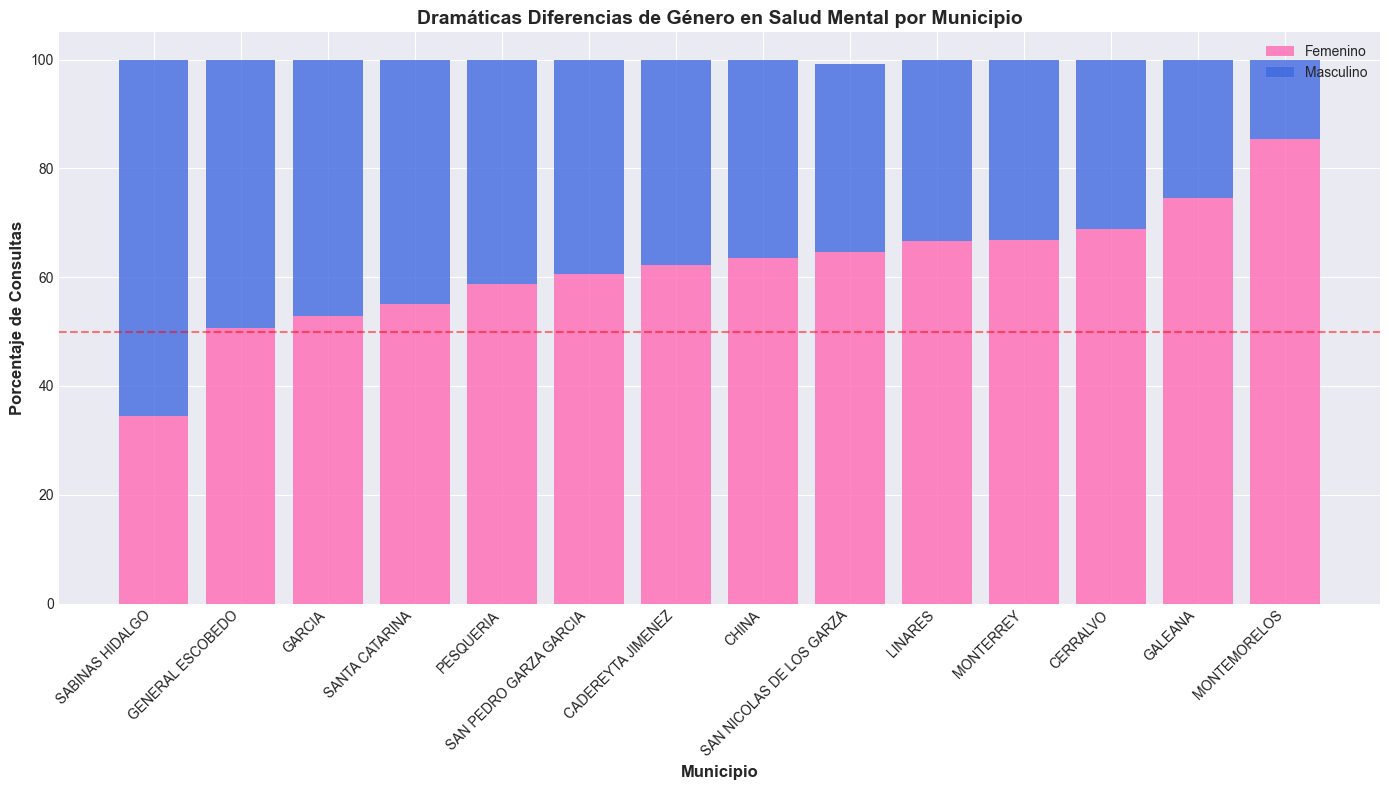

In [19]:
# Gráfico de diferencias de género por municipio
plt.figure(figsize=(14, 8))

# Ordenar municipios por porcentaje femenino
municipios_ordenados = df_genero.sort_values('%_femenino')['municipio']
porcentajes_f = df_genero.sort_values('%_femenino')['%_femenino']
porcentajes_m = df_genero.sort_values('%_femenino')['%_masculino']

# Crear gráfico de barras apiladas
bar_width = 0.8
bars_f = plt.bar(range(len(municipios_ordenados)), porcentajes_f, bar_width, 
                 label='Femenino', color='#FF69B4', alpha=0.8)
bars_m = plt.bar(range(len(municipios_ordenados)), porcentajes_m, bar_width, 
                 bottom=porcentajes_f, label='Masculino', color='#4169E1', alpha=0.8)

plt.xlabel('Municipio', fontsize=12, fontweight='bold')
plt.ylabel('Porcentaje de Consultas', fontsize=12, fontweight='bold')
plt.title('Dramáticas Diferencias de Género en Salud Mental por Municipio', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(municipios_ordenados)), municipios_ordenados, rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# Agregar línea del 50% para referencia
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Equilibrio (50%)')

plt.savefig('diferencias_genero_municipio.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# =============================================================================
# 7. ANÁLISIS DE FACTORES FISIOLÓGICOS (IMC, EDAD, GÉNERO)
# =============================================================================

# Distribución de edad por diagnóstico
edad_por_diagnostico = df.groupby('descripcion_enfermedad')['edad'].agg(['mean', 'median', 'std', 'count'])
edad_por_diagnostico = edad_por_diagnostico[edad_por_diagnostico['count'] > 50]  # Filtrar diagnósticos frecuentes
edad_por_diagnostico = edad_por_diagnostico.sort_values('count', ascending=False)  # Ordenar por count descendente
print("\n=== EDAD PROMEDIO POR DIAGNÓSTICO (ordenado por frecuencia) ===")
edad_por_diagnostico.head(20)


=== EDAD PROMEDIO POR DIAGNÓSTICO (ordenado por frecuencia) ===


,mean,median,std,count
descripcion_enfermedad,,,,
TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION,35.175791,32.0,17.662793,5626
EPISODIO DEPRESIVO LEVE,33.185714,28.0,19.128153,3080
ESQUIZOFRENIA PARANOIDE,43.972937,45.0,13.466298,2993
TRASTORNO DE ANSIEDAD GENERALIZADA,36.429260,34.0,17.061848,2905
EPISODIO DEPRESIVO MODERADO,32.540878,27.0,17.046224,2165
PSICOTERAPIA NO CLASIFICADA EN OTRA PARTE,35.208262,32.0,17.476397,1743
PERTURBACION DE LA ACTIVIDAD Y DE LA ATENCION,12.699399,12.0,6.714415,1497
TRASTORNOS MENTALES Y DEL COMPORTAMIENTO DEBIDOS AL USO DE MULTIPLES DROGAS Y AL USO DE OTRAS SUSTANCIAS PSICOACTIVAS SINDROME DE DEPENDENDENCIA,29.542373,29.0,8.974633,1239
ABUSO PSICOLOGICO,36.875208,35.0,16.024733,1202


In [33]:

# Distribución por género
genero_por_diagnostico = df.groupby(['descripcion_enfermedad', 'sexo']).size().unstack(fill_value=0)
genero_por_diagnostico['total'] = genero_por_diagnostico.sum(axis=1)
genero_por_diagnostico = genero_por_diagnostico[genero_por_diagnostico['total'] > 50]
genero_por_diagnostico['porcentaje_femenino'] = (genero_por_diagnostico['Femenino'] / genero_por_diagnostico['total'] * 100).round(1)
print("\n=== PORCENTAJE FEMENINO POR DIAGNÓSTICO ===")
print(genero_por_diagnostico[['Femenino', 'Masculino', 'porcentaje_femenino']].head(10))

# Análisis de IMC por diagnóstico
imc_por_diagnostico = df.groupby('descripcion_enfermedad')['imc'].agg(['mean', 'median', 'std', 'count'])
imc_por_diagnostico = imc_por_diagnostico[imc_por_diagnostico['count'] > 20]  # Filtrar con suficientes datos
print("\n=== IMC PROMEDIO POR DIAGNÓSTICO ===")
print(imc_por_diagnostico.head(10))


=== PORCENTAJE FEMENINO POR DIAGNÓSTICO ===
sexo                                                Femenino  Masculino  \
descripcion_enfermedad                                                    
ABUSO PSICOLOGICO                                       1163         39   
ABUSO SEXUAL                                             167         80   
AGORAFOBIA                                                47         19   
AUTISMO ATIPICO                                           53        101   
AUTISMO EN LA NINEZ                                       96        319   
CONSULTA PARA ASESORIA Y VIGILANCIA POR ABUSO D...        45        315   
DISTIMIA                                                 224         77   
EPILEPSIA Y SINDROMES EPILEPTICOS IDIOPATICOS G...       116         88   
EPILEPSIA Y SINDROMES EPILEPTICOS IDIOPATICOS R...        93         80   
EPISODIO DEPRESIVO GRAVE CON SINTOMAS PSICOTICOS         130         47   

sexo                                                po

In [34]:
# =============================================================================
# ANÁLISIS COMPLETO: GÉNERO Y EDAD POR MUNICIPIO
# =============================================================================

print("\n=== ANÁLISIS INTEGRAL: GÉNERO Y EDAD POR MUNICIPIO ===\n")

# Crear lista para almacenar datos completos
datos_completos = []

for municipio in df['municipio_unidad_medica'].unique():
    municipio_data = df[df['municipio_unidad_medica'] == municipio]
    total = len(municipio_data)
    
    # Análisis de género
    femenino = len(municipio_data[municipio_data['sexo'] == 'Femenino'])
    masculino = len(municipio_data[municipio_data['sexo'] == 'Masculino'])
    porcentaje_femenino = round(femenino / total * 100, 1)
    porcentaje_masculino = round(masculino / total * 100, 1)
    
    # Análisis de edad
    edad_promedio = round(municipio_data['edad'].mean(), 1)
    edad_min = int(municipio_data['edad'].min())
    edad_max = int(municipio_data['edad'].max())
    edad_mediana = round(municipio_data['edad'].median(), 1)
    
    # Edad por género
    edad_femenino = round(municipio_data[municipio_data['sexo'] == 'Femenino']['edad'].mean(), 1)
    edad_masculino = round(municipio_data[municipio_data['sexo'] == 'Masculino']['edad'].mean(), 1)
    
    # Top diagnóstico
    top_diagnostico = municipio_data['descripcion_enfermedad'].value_counts().head(1)
    nombre_top = top_diagnostico.index[0] if len(top_diagnostico) > 0 else "N/A"
    count_top = top_diagnostico.values[0] if len(top_diagnostico) > 0 else 0
    
    datos_completos.append({
        'municipio': municipio,
        'total_consultas': total,
        'femenino_count': femenino,
        'masculino_count': masculino,
        '%_femenino': porcentaje_femenino,
        '%_masculino': porcentaje_masculino,
        'edad_promedio': edad_promedio,
        'edad_min': edad_min,
        'edad_max': edad_max,
        'edad_mediana': edad_mediana,
        'edad_femenino': edad_femenino,
        'edad_masculino': edad_masculino,
        'top_diagnostico': nombre_top,
        'top_diagnostico_count': count_top
    })
    
    # Imprimir resumen por municipio
    print(f"{'='*60}")
    print(f"MUNICIPIO: {municipio}")
    print(f"{'='*60}")
    print(f"📊 Total consultas: {total}")
    print(f"\n👥 GÉNERO:")
    print(f"   Femenino: {femenino} ({porcentaje_femenino}%)")
    print(f"   Masculino: {masculino} ({porcentaje_masculino}%)")
    print(f"\n📈 EDAD:")
    print(f"   Promedio general: {edad_promedio} años")
    print(f"   Rango: {edad_min} - {edad_max} años")
    print(f"   Mediana: {edad_mediana} años")
    print(f"   Promedio mujeres: {edad_femenino} años")
    print(f"   Promedio hombres: {edad_masculino} años")
    print(f"\n🏆 DIAGNÓSTICO PRINCIPAL:")
    print(f"   {nombre_top}: {count_top} casos")
    print()

# Crear DataFrame para análisis
df_completo = pd.DataFrame(datos_completos)

# Ordenar por diferentes criterios
print("\n" + "="*60)
print("RANKINGS POR DIFERENTES CRITERIOS")
print("="*60)

print("\n📊 MUNICIPIOS CON MÁS CONSULTAS:")
print(df_completo.nlargest(5, 'total_consultas')[['municipio', 'total_consultas', '%_femenino', 'edad_promedio']])

print("\n👩 MUNICIPIOS CON MAYOR PORCENTAJE FEMENINO:")
print(df_completo.nlargest(5, '%_femenino')[['municipio', '%_femenino', 'edad_promedio', 'edad_femenino']])

print("\n👨 MUNICIPIOS CON MAYOR PORCENTAJE MASCULINO:")
print(df_completo.nlargest(5, '%_masculino')[['municipio', '%_masculino', 'edad_promedio', 'edad_masculino']])

print("\n👶 MUNICIPIOS CON POBLACIÓN MÁS JOVEN (edad promedio):")
print(df_completo.nsmallest(5, 'edad_promedio')[['municipio', 'edad_promedio', '%_femenino']])

print("\n👴 MUNICIPIOS CON POBLACIÓN MÁS ADULTA (edad promedio):")
print(df_completo.nlargest(5, 'edad_promedio')[['municipio', 'edad_promedio', '%_femenino']])


=== ANÁLISIS INTEGRAL: GÉNERO Y EDAD POR MUNICIPIO ===

MUNICIPIO: LINARES
📊 Total consultas: 138

👥 GÉNERO:
   Femenino: 92 (66.7%)
   Masculino: 46 (33.3%)

📈 EDAD:
   Promedio general: 41.2 años
   Rango: 3 - 97 años
   Mediana: 38.0 años
   Promedio mujeres: 38.5 años
   Promedio hombres: 46.4 años

🏆 DIAGNÓSTICO PRINCIPAL:
   TRASTORNO DE ANSIEDAD NO ESPECIFICADO: 47 casos

MUNICIPIO: MONTEMORELOS
📊 Total consultas: 802

👥 GÉNERO:
   Femenino: 685 (85.4%)
   Masculino: 117 (14.6%)

📈 EDAD:
   Promedio general: 29.7 años
   Rango: 4 - 93 años
   Mediana: 25.0 años
   Promedio mujeres: 28.3 años
   Promedio hombres: 38.2 años

🏆 DIAGNÓSTICO PRINCIPAL:
   OTROS TRASTORNOS MENTALES Y DEL COMPORTAMIENTO ASOCIADOS CON EL PUERPERIO NO CLASIFICADOS EN OTRA PARTE: 406 casos

MUNICIPIO: MONTERREY
📊 Total consultas: 15544

👥 GÉNERO:
   Femenino: 10378 (66.8%)
   Masculino: 5166 (33.2%)

📈 EDAD:
   Promedio general: 32.6 años
   Rango: 1 - 118 años
   Mediana: 29.0 años
   Promedio mujeres: 

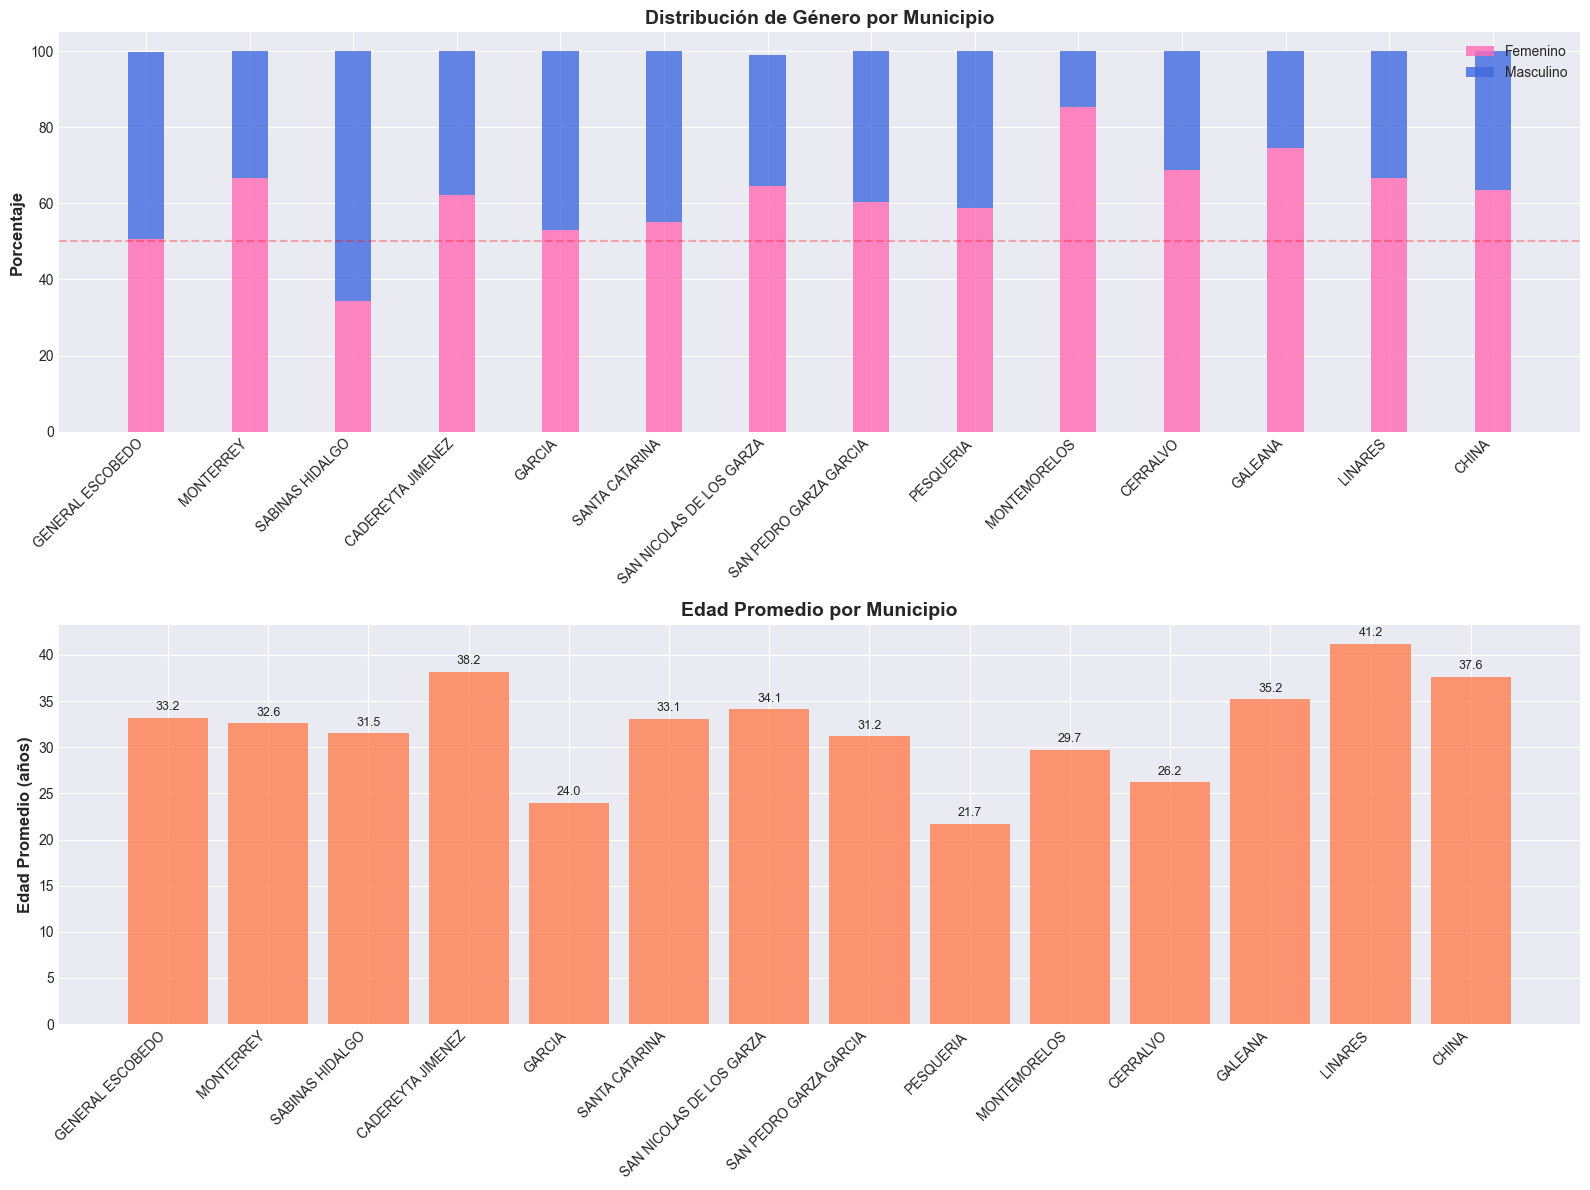

In [35]:
# Gráfico combinado: Género y Edad por municipio
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Ordenar por total de consultas
df_ordenado = df_completo.sort_values('total_consultas', ascending=False)
municipios = df_ordenado['municipio']

# Gráfico 1: Distribución de género
width = 0.35
bars_f = ax1.bar(range(len(municipios)), df_ordenado['%_femenino'], width, 
                 label='Femenino', color='#FF69B4', alpha=0.8)
bars_m = ax1.bar(range(len(municipios)), df_ordenado['%_masculino'], width, 
                 bottom=df_ordenado['%_femenino'], label='Masculino', color='#4169E1', alpha=0.8)

ax1.set_ylabel('Porcentaje', fontsize=12, fontweight='bold')
ax1.set_title('Distribución de Género por Municipio', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(municipios)))
ax1.set_xticklabels(municipios, rotation=45, ha='right')
ax1.legend()
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.3, label='Equilibrio')

# Gráfico 2: Edad promedio
bars_edad = ax2.bar(range(len(municipios)), df_ordenado['edad_promedio'], 
                    color='coral', alpha=0.8)
ax2.set_ylabel('Edad Promedio (años)', fontsize=12, fontweight='bold')
ax2.set_title('Edad Promedio por Municipio', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(municipios)))
ax2.set_xticklabels(municipios, rotation=45, ha='right')

# Agregar valores sobre las barras
for i, (bar, valor) in enumerate(zip(bars_edad, df_ordenado['edad_promedio'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{valor:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('genero_edad_municipios.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# =============================================================================
# ANÁLISIS DE GRUPOS DE EDAD POR MUNICIPIO
# =============================================================================

print("\n=== GRUPOS DE EDAD POR MUNICIPIO ===\n")

# Definir grupos de edad
bins = [0, 12, 18, 25, 35, 50, 65, 100]
labels = ['0-11', '12-17', '18-24', '25-34', '35-49', '50-64', '65+']

for municipio in df['municipio_unidad_medica'].unique():
    municipio_data = df[df['municipio_unidad_medica'] == municipio].copy()
    municipio_data['grupo_edad'] = pd.cut(municipio_data['edad'], bins=bins, labels=labels)
    
    distribucion_edad = municipio_data['grupo_edad'].value_counts().sort_index()
    
    print(f"{municipio}:")
    for grupo, count in distribucion_edad.items():
        porcentaje = round(count / len(municipio_data) * 100, 1)
        print(f"  {grupo}: {count} ({porcentaje}%)")
    print()


=== GRUPOS DE EDAD POR MUNICIPIO ===

LINARES:
  0-11: 10 (7.2%)
  12-17: 10 (7.2%)
  18-24: 31 (22.5%)
  25-34: 14 (10.1%)
  35-49: 28 (20.3%)
  50-64: 14 (10.1%)
  65+: 31 (22.5%)

MONTEMORELOS:
  0-11: 24 (3.0%)
  12-17: 155 (19.3%)
  18-24: 238 (29.7%)
  25-34: 174 (21.7%)
  35-49: 103 (12.8%)
  50-64: 77 (9.6%)
  65+: 31 (3.9%)

MONTERREY:
  0-11: 1414 (9.1%)
  12-17: 3215 (20.7%)
  18-24: 2328 (15.0%)
  25-34: 2367 (15.2%)
  35-49: 3188 (20.5%)
  50-64: 2369 (15.2%)
  65+: 662 (4.3%)

SABINAS HIDALGO:
  0-11: 0 (0.0%)
  12-17: 379 (11.0%)
  18-24: 821 (23.9%)
  25-34: 1267 (36.9%)
  35-49: 668 (19.4%)
  50-64: 251 (7.3%)
  65+: 49 (1.4%)

SAN NICOLAS DE LOS GARZA:
  0-11: 214 (19.5%)
  12-17: 166 (15.1%)
  18-24: 88 (8.0%)
  25-34: 150 (13.6%)
  35-49: 154 (14.0%)
  50-64: 235 (21.4%)
  65+: 93 (8.5%)

SANTA CATARINA:
  0-11: 58 (4.9%)
  12-17: 170 (14.4%)
  18-24: 218 (18.4%)
  25-34: 299 (25.3%)
  35-49: 248 (21.0%)
  50-64: 147 (12.4%)
  65+: 43 (3.6%)

GENERAL ESCOBEDO:
  0-

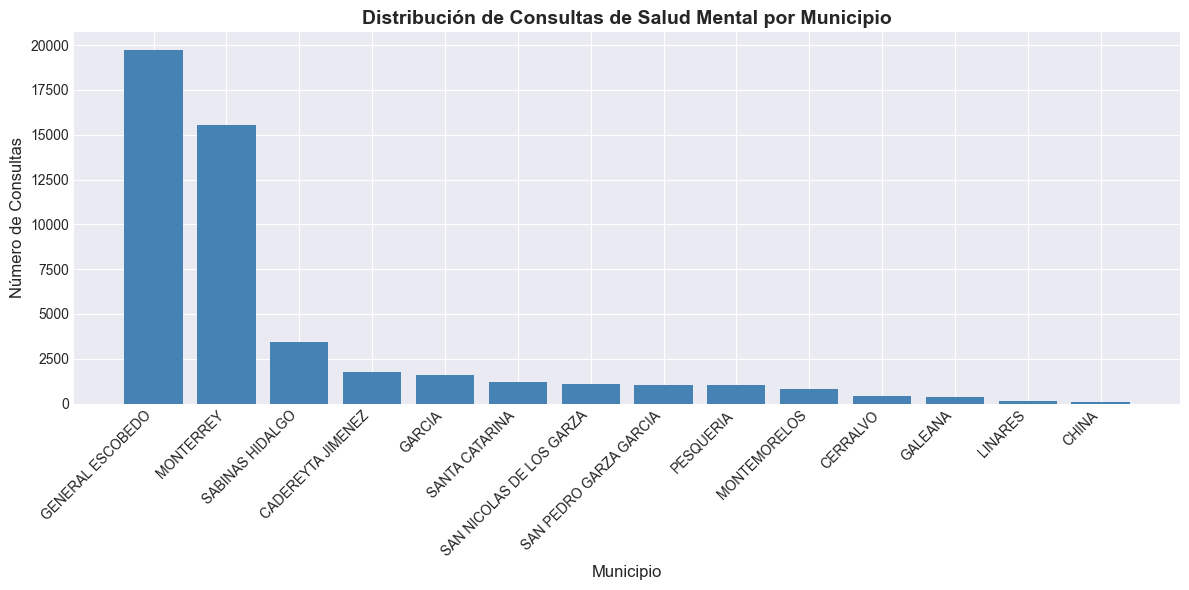

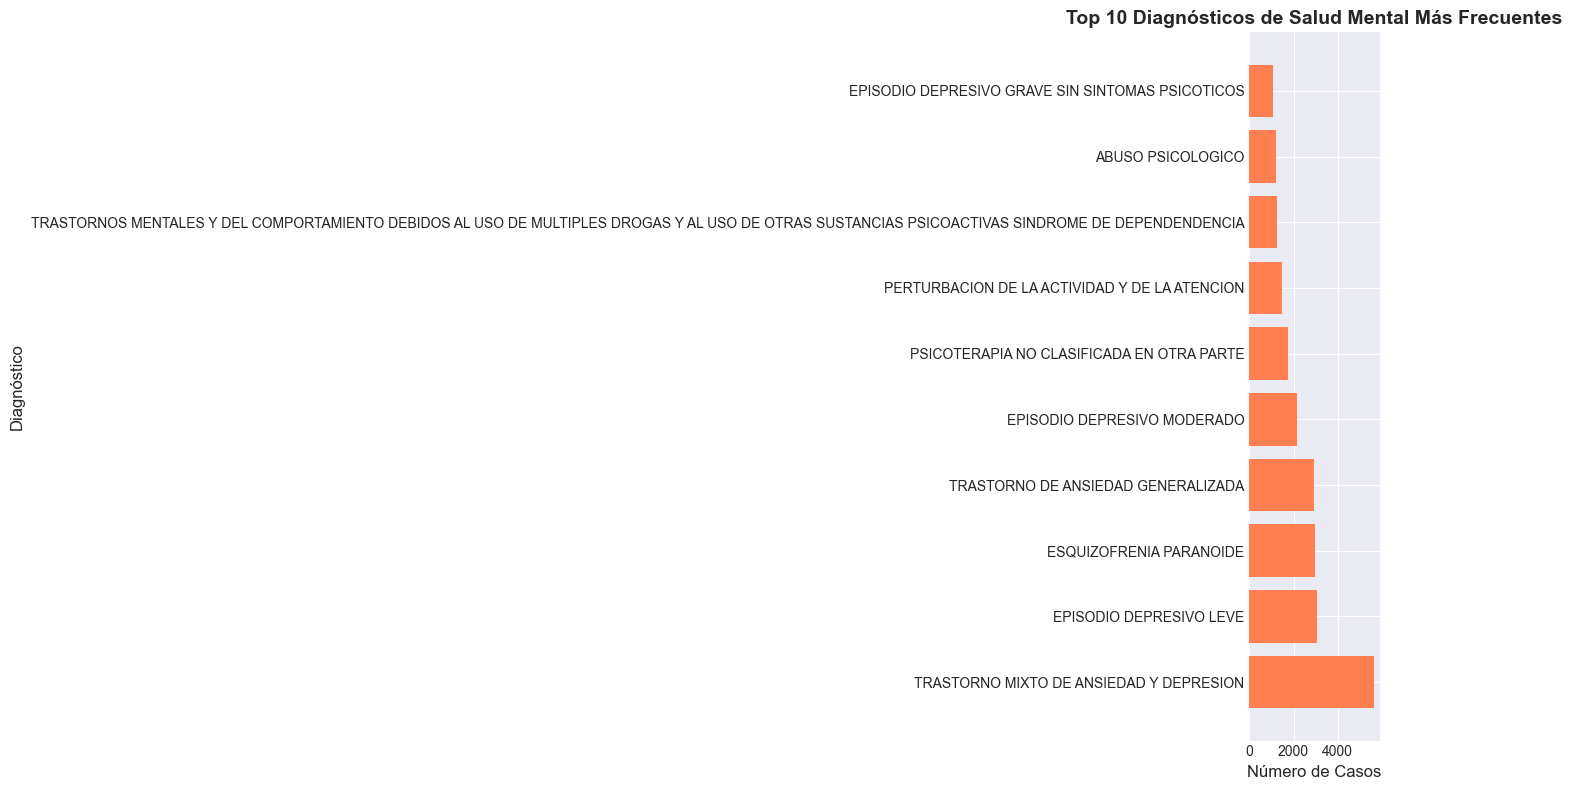

<Figure size 1200x600 with 0 Axes>

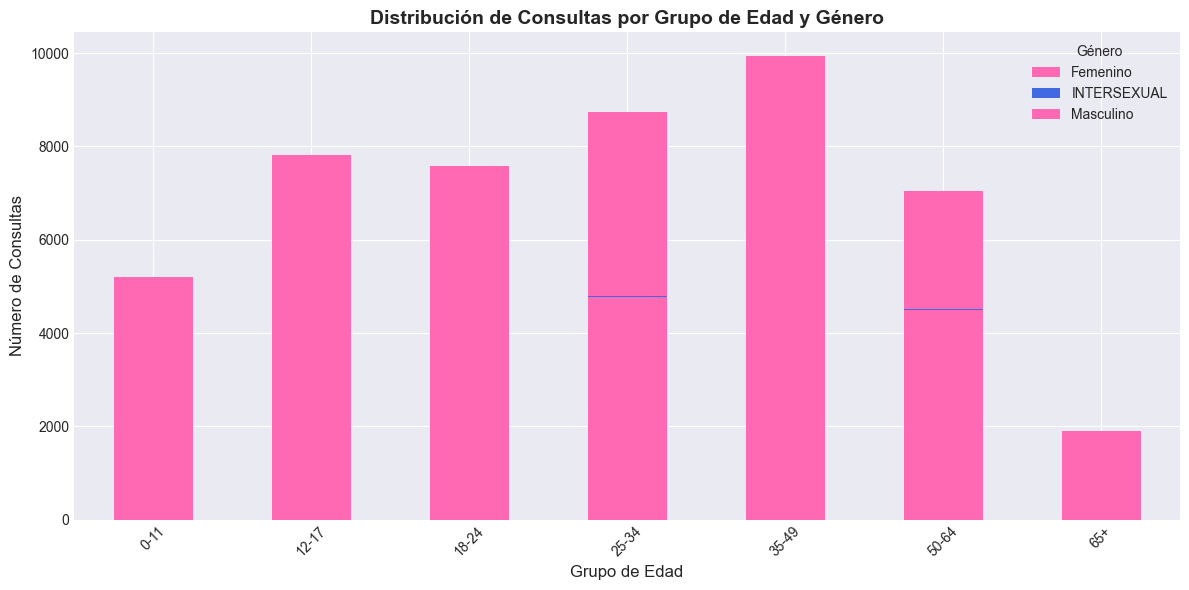

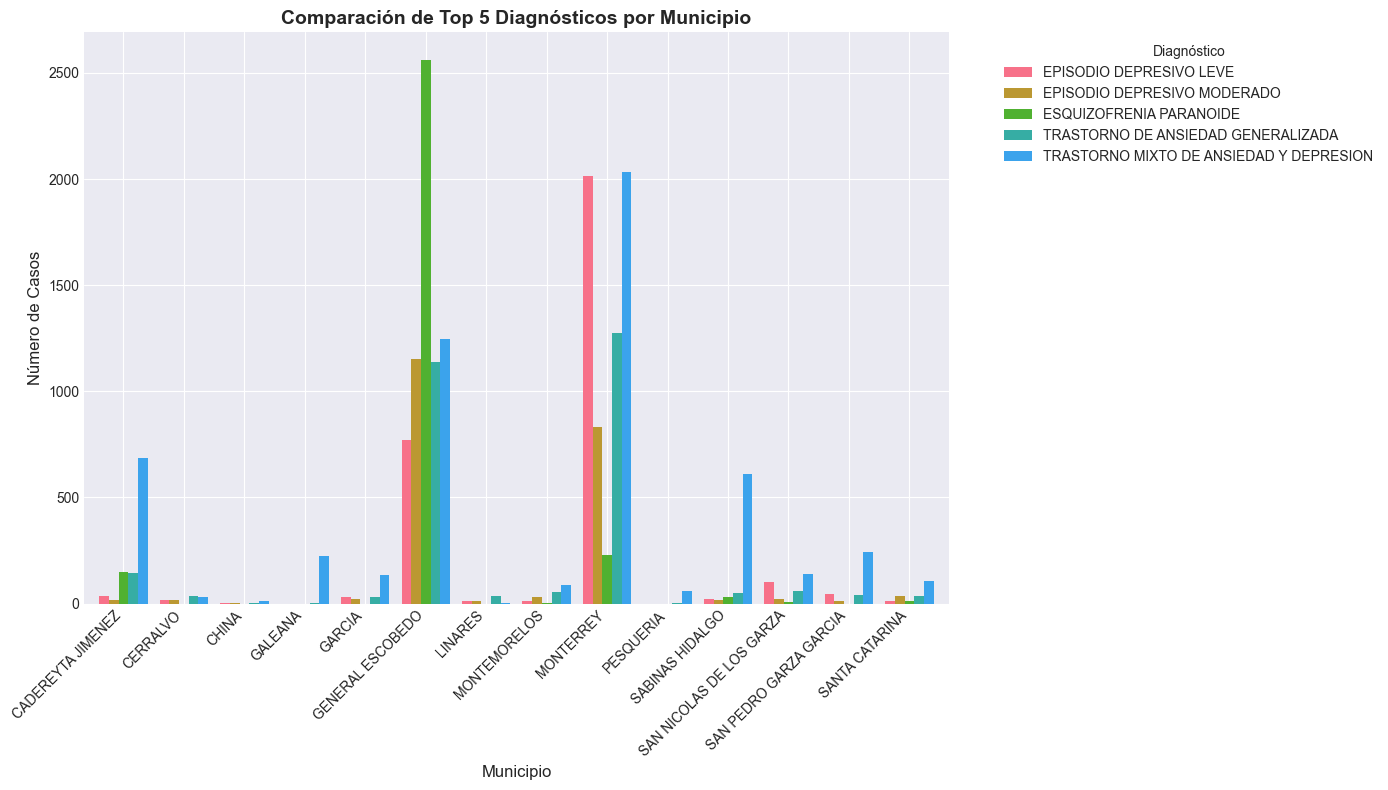

<Figure size 1200x600 with 0 Axes>

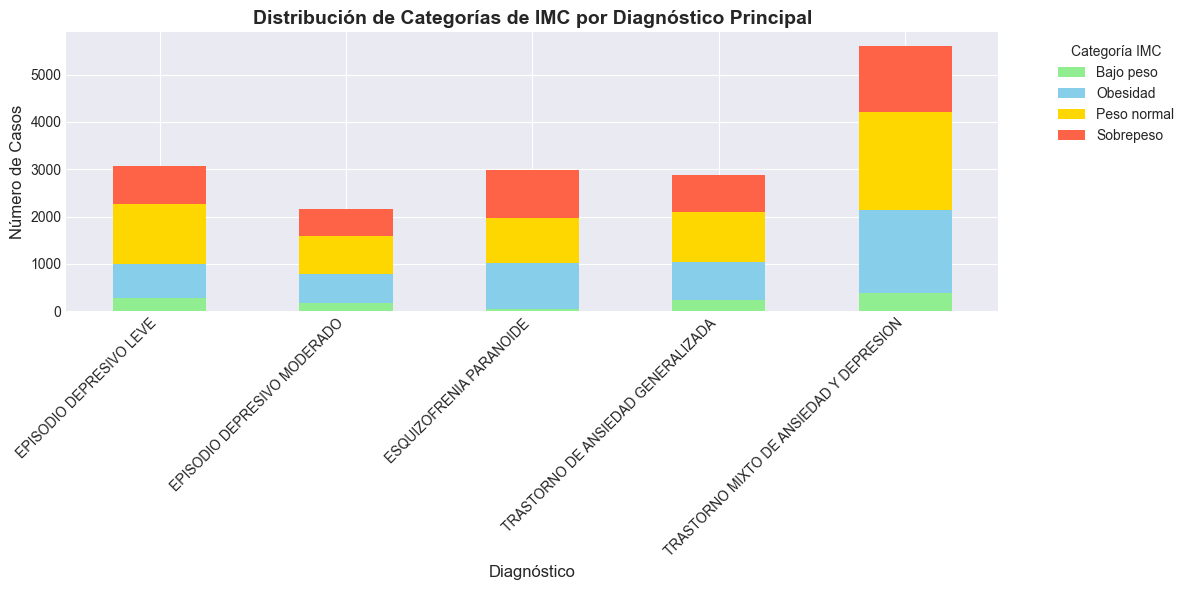

In [21]:
# =============================================================================
# 8. VISUALIZACIONES PARA INFOGRAFÍA
# =============================================================================

# Figura 1: Distribución de consultas por municipio
plt.figure(figsize=(12, 6))
municipio_counts = df['municipio_unidad_medica'].value_counts()
plt.bar(municipio_counts.index, municipio_counts.values, color='steelblue')
plt.title('Distribución de Consultas de Salud Mental por Municipio', fontsize=14, fontweight='bold')
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Número de Consultas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('distribucion_municipios.png', dpi=300, bbox_inches='tight')
plt.show()

# Figura 2: Top 10 diagnósticos más frecuentes
plt.figure(figsize=(14, 8))
top_diagnosticos = df['descripcion_enfermedad'].value_counts().head(10)
plt.barh(top_diagnosticos.index, top_diagnosticos.values, color='coral')
plt.title('Top 10 Diagnósticos de Salud Mental Más Frecuentes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Casos', fontsize=12)
plt.ylabel('Diagnóstico', fontsize=12)
plt.tight_layout()
plt.savefig('top_diagnosticos.png', dpi=300, bbox_inches='tight')
plt.show()

# Figura 3: Distribución por edad y género
plt.figure(figsize=(12, 6))
edad_bins = [0, 12, 18, 25, 35, 50, 65, 100]
edad_labels = ['0-11', '12-17', '18-24', '25-34', '35-49', '50-64', '65+']
df['grupo_edad'] = pd.cut(df['edad'], bins=edad_bins, labels=edad_labels)

edad_genero = df.groupby(['grupo_edad', 'sexo']).size().unstack(fill_value=0)
edad_genero.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#FF69B4', '#4169E1'])
plt.title('Distribución de Consultas por Grupo de Edad y Género', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Número de Consultas', fontsize=12)
plt.legend(title='Género')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('distribucion_edad_genero.png', dpi=300, bbox_inches='tight')
plt.show()

# Figura 4: Comparación de diagnósticos principales por municipio
top_5_diagnosticos = df['descripcion_enfermedad'].value_counts().head(5).index
municipio_diagnostico = df[df['descripcion_enfermedad'].isin(top_5_diagnosticos)]
municipio_diagnostico_pivot = municipio_diagnostico.groupby(['municipio_unidad_medica', 'descripcion_enfermedad']).size().unstack(fill_value=0)

municipio_diagnostico_pivot.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('Comparación de Top 5 Diagnósticos por Municipio', fontsize=14, fontweight='bold')
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.legend(title='Diagnóstico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('comparacion_municipios.png', dpi=300, bbox_inches='tight')
plt.show()

# Figura 5: Categorías de IMC por diagnóstico
plt.figure(figsize=(12, 6))
imc_diagnostico = df[df['categoria_imc'] != 'Sin dato']
imc_diagnostico = imc_diagnostico[imc_diagnostico['descripcion_enfermedad'].isin(top_5_diagnosticos)]
imc_pivot = imc_diagnostico.groupby(['descripcion_enfermedad', 'categoria_imc']).size().unstack(fill_value=0)

imc_pivot.plot(kind='bar', stacked=True, figsize=(12, 6), 
               color=['#90EE90', '#87CEEB', '#FFD700', '#FF6347'])
plt.title('Distribución de Categorías de IMC por Diagnóstico Principal', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.legend(title='Categoría IMC', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imc_por_diagnostico.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:

# =============================================================================
# 9. ANÁLISIS DE BRECHAS Y DESIGUALDADES
# =============================================================================

# Calcular índice de diversidad de diagnósticos por municipio
def calcular_diversidad(grupo):
    """Calcula la diversidad usando el índice de Shannon"""
    counts = grupo.value_counts(normalize=True)
    if len(counts) == 0:
        return 0
    return -np.sum(counts * np.log(counts))

diversidad_municipios = df.groupby('municipio_unidad_medica')['descripcion_enfermedad'].apply(calcular_diversidad)
print("\n=== ÍNDICE DE DIVERSIDAD DE DIAGNÓSTICOS POR MUNICIPIO ===")
print(diversidad_municipios)

# Análisis de acceso a servicios especializados
servicios_especializados = df[df['institucion_unidad_medica'].str.contains('SALUD MENTAL|ADICCIONES', case=False, na=False)]
acceso_especializado = servicios_especializados.groupby('municipio_unidad_medica').size() / df.groupby('municipio_unidad_medica').size() * 100
print("\n=== PORCENTAJE DE ACCESO A SERVICIOS ESPECIALIZADOS ===")
print(acceso_especializado)


=== ÍNDICE DE DIVERSIDAD DE DIAGNÓSTICOS POR MUNICIPIO ===
municipio_unidad_medica
CADEREYTA JIMENEZ           2.754691
CERRALVO                    3.339479
CHINA                       3.238576
GALEANA                     1.687549
GARCIA                      3.540679
GENERAL ESCOBEDO            3.900432
LINARES                     2.084733
MONTEMORELOS                2.054441
MONTERREY                   3.586433
PESQUERIA                   2.918199
SABINAS HIDALGO             2.675279
SAN NICOLAS DE LOS GARZA    3.076531
SAN PEDRO GARZA GARCIA      3.227133
SANTA CATARINA              3.172443
Name: descripcion_enfermedad, dtype: float64

=== PORCENTAJE DE ACCESO A SERVICIOS ESPECIALIZADOS ===
municipio_unidad_medica
CADEREYTA JIMENEZ             4.635387
CERRALVO                    100.000000
CHINA                       100.000000
GALEANA                            NaN
GARCIA                       43.944198
GENERAL ESCOBEDO             91.580921
LINARES                            NaN

In [23]:
# =============================================================================
# 10. RESUMEN EJECUTIVO PARA INFOGRAFÍA
# =============================================================================

print("\n" + "="*60)
print("RESUMEN EJECUTIVO - DATATÓN DE CHEVES Y DATOS 2026")
print("="*60)

print(f"\n📊 TOTAL DE CONSULTAS ANALIZADAS: {len(df):,}")
print(f"📍 MUNICIPIOS REPRESENTADOS: {df['municipio_unidad_medica'].nunique()}")
print(f"🏥 INSTITUCIONES MÉDICAS: {df['institucion_unidad_medica'].nunique()}")
print(f"🔬 TIPOS DE DIAGNÓSTICOS: {df['descripcion_enfermedad'].nunique()}")

print(f"\n👥 DISTRIBUCIÓN POR GÉNERO:")
for genero, count in df['sexo'].value_counts().items():
    porcentaje = (count / len(df) * 100).round(1)
    print(f"   {genero}: {count:,} ({porcentaje}%)")

print(f"\n📈 EDAD PROMEDIO: {df['edad'].mean():.1f} años")
print(f"📊 RANGO DE EDAD: {df['edad'].min():.0f} - {df['edad'].max():.0f} años")

print(f"\n🏆 TOP 3 DIAGNÓSTICOS MÁS FRECUENTES:")
for i, (diagnostico, count) in enumerate(df['descripcion_enfermedad'].value_counts().head(3).items(), 1):
    porcentaje = (count / len(df) * 100).round(1)
    print(f"   {i}. {diagnostico}: {count:,} casos ({porcentaje}%)")

print(f"\n🗺️ MUNICIPIO CON MÁS CONSULTAS: {df['municipio_unidad_medica'].value_counts().index[0]}")
print(f"   Total: {df['municipio_unidad_medica'].value_counts().values[0]:,} consultas")

print(f"\n⚠️ REGISTROS DE CAUSAS EXTERNAS: {len(causas_externas):,}")
if len(causas_externas) > 0:
    print(f"   Incluye maltratos y otros factores externos que pueden relacionarse con salud mental")

print(f"\n💪 DATOS DE IMC DISPONIBLES: {df['imc'].notna().sum():,} ({(df['imc'].notna().sum()/len(df)*100).round(1)}%)")
print(f"   IMC promedio: {df['imc'].mean():.1f}")

print("\n" + "="*60)
print("FIN DEL ANÁLISIS")
print("="*60)


RESUMEN EJECUTIVO - DATATÓN DE CHEVES Y DATOS 2026

📊 TOTAL DE CONSULTAS ANALIZADAS: 48,224
📍 MUNICIPIOS REPRESENTADOS: 14
🏥 INSTITUCIONES MÉDICAS: 32
🔬 TIPOS DE DIAGNÓSTICOS: 435

👥 DISTRIBUCIÓN POR GÉNERO:


AttributeError: 'float' object has no attribute 'round'